<img src="https://raw.githubusercontent.com/AllenSWDB/allenswdb.github.io/main/databook/resources/swdb_logo_new.jpg">  

# Extension 1: Power Curves and Leave-one-out Cross Validation



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">


*Building on Part 2 (valid workflows) and Part 3 (a simulated real effect).*

The train/test split from Part 2 breaks the circularity, but it throws away half the data for
each of selection and testing. Here we develop two further refinements:

1. **Leave-one-out cross-validation (LOO-CV):** a more data-efficient valid method.
2. **Permutation testing:** the correct way to get a p-value for the (dependent) LOO-CV
   statistic, fixing a residual inflation in the naive analytic test.

Additionally, we explore

3. **Power curves:** a way of measuring data efficiency to compare across methods.

This notebook is self-contained: the shared building blocks from Parts 1–3 are imported from
`utils.py`. `loo_cv_PRCA` is (re)defined inline here because this is where it is first
introduced.

</div>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import sys
sys.path.append("/code")
from utils import simulate_null_session, simulate_real_effect, train_test_PRCA, fdr_bh_cells

# Set a seed so the notebook is reproducible (remove for fresh random draws)
rng = np.random.default_rng(0)

Ngroups, Ncells = 20, 200
mean_perf, sd_perf, sd_dff = 75, 8, 1

# Null session (Part 1) and real-effect sessions (Part 3), so we can compare methods.
Perf, DA, CellXY = simulate_null_session(rng, Ngroups, Ncells, mean_perf, sd_perf, sd_dff)

Nresponsive = round(0.1 * Ncells)
CorrelatedCells = np.arange(0, Nresponsive)

k = 0.2
DA_real = simulate_real_effect(rng, Perf, Ncells, CorrelatedCells, k, sd_dff)

k_strong = 0.6
DA_real_strong = simulate_real_effect(rng, Perf, Ncells, CorrelatedCells, k_strong, sd_dff)



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

## Leave-one-out cross-validation
A problem with the simple train-test split solution from Part 2 is that it reduces our effect dataset size by half, leaving us with less ability to detect real effects.

With only 20 trial groups, **leave-one-out cross-validation (LOO-CV)** is a natural choice:

* **Fold $i$** (for $i = 1 \ldots N_\text{groups}$):
  1. Use the $N_\text{groups} - 1$ *training* trial groups to select cells
     (same criteria as before: $r > 0.1$, $p < 0.05$).
  2. Compute the PRCA for the *held-out* trial group $i$ by averaging the
     activity in those training-derived cells.

After all folds, the held-out PRCA values are assembled into a vector of length
$N_\text{groups}$ and correlated with $P$.  Because no trial group's data influenced both the
cell-selection step and its own PRCA value, this correlation is (mostly) independent.

The helper below implements the loop; it returns `PRCA_cv` (one entry per trial group) and
the number of cells selected in each fold (useful for diagnostics).

</div>


In [2]:
def loo_cv_PRCA(DA, Perf):
    """Leave-one-out cross-validated PRCA.

    For each held-out trial group i, cells are selected on the other N-1 trial groups
    using the same criteria as the Proposed analysis (r > 0.1, p < 0.05),
    then PRCA is computed for trial group i on those held-out cells.

    Returns
    -------
    PRCA_cv : ndarray, shape (Ngroups,)
        Cross-validated PRCA; NaN where no cells were selected in that fold.
    n_cells : list of int
        Number of cells selected in each fold (diagnostic).
    """
    Ngroups = DA.shape[0]
    PRCA_cv = np.full(Ngroups, np.nan)
    n_cells = []

    for i in range(Ngroups):
        train_idx = np.delete(np.arange(Ngroups), i)
        # Correlate every cell with performance on the training folds (vectorized pearsonr).
        res = stats.pearsonr(DA[train_idx], Perf[train_idx][:, np.newaxis], axis=0)
        sel_cells = np.where((res.statistic > 0.1) & (res.pvalue < 0.05))[0]
        n_cells.append(sel_cells.size)
        if sel_cells.size > 0:
            PRCA_cv[i] = DA[i, sel_cells].mean()

    return PRCA_cv, n_cells


In [3]:
# Apply LOO-CV to the null dataset
PRCA_cv_null, ncells_null = loo_cv_PRCA(DA, Perf)

print("Null data (no real effect):")
print(f"  Avg cells selected per fold : {np.mean(ncells_null):.1f}  "
      f"(range {min(ncells_null)}–{max(ncells_null)})")
print(f"  Folds with ≥1 cell selected : {np.sum(np.array(ncells_null) > 0)}/{Ngroups}")


Null data (no real effect):
  Avg cells selected per fold : 6.3  (range 5–9)
  Folds with ≥1 cell selected : 20/20



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

### False-positive rate — adding LOO-CV to the comparison

To see where LOO-CV lands, we repeat the **null simulation** (no real effect) many times and
count how often each method incorrectly declares a significant result, alongside the circular,
train/test split, and FDR-BH methods from earlier notebooks. At $\alpha = 0.05$ the nominal
false-positive rate is 5%.

</div>


In [4]:
N_iter2 = 1000
alpha2 = 0.05

counts = {"circular": 0, "split": 0, "fdr_bh": 0, "cv": 0}

for _ in range(N_iter2):
    DA_mc = sd_dff * rng.standard_normal((Ngroups, Ncells))

    # Circular (Part 1)
    res_mc = stats.pearsonr(DA_mc, Perf[:, np.newaxis], axis=0)
    sel_mc = np.where((res_mc.statistic > 0.1) & (res_mc.pvalue < 0.05))[0]
    if sel_mc.size > 0:
        _, p_circ = stats.pearsonr(DA_mc[:, sel_mc].mean(axis=1), Perf)
        if p_circ < alpha2:
            counts["circular"] += 1

    # 50/50 train/test split (Part 2)
    tt = train_test_PRCA(DA_mc, Perf)
    if tt is not None and tt[0].size >= 3:
        _, p_tt = stats.pearsonr(tt[0], tt[1])
        if p_tt < alpha2:
            counts["split"] += 1

    # FDR-BH (Part 2)
    if fdr_bh_cells(DA_mc, Perf, q=alpha2).size > 0:
        counts["fdr_bh"] += 1

    # LOO-CV (this notebook)
    PRCA_cv, _ = loo_cv_PRCA(DA_mc, Perf)
    _, p_cv = stats.pearsonr(PRCA_cv, Perf)
    if p_cv < alpha2:
        counts["cv"] += 1

for name, cnt in counts.items():
    print(f"  {name:10s}  FP rate = {cnt/N_iter2:.1%}  ({cnt}/{N_iter2})")
print(f"  nominal α  = {alpha2:.1%}")


  circular    FP rate = 99.2%  (992/1000)
  split       FP rate = 4.0%  (40/1000)
  fdr_bh      FP rate = 4.3%  (43/1000)
  cv          FP rate = 22.8%  (228/1000)
  nominal α  = 5.0%


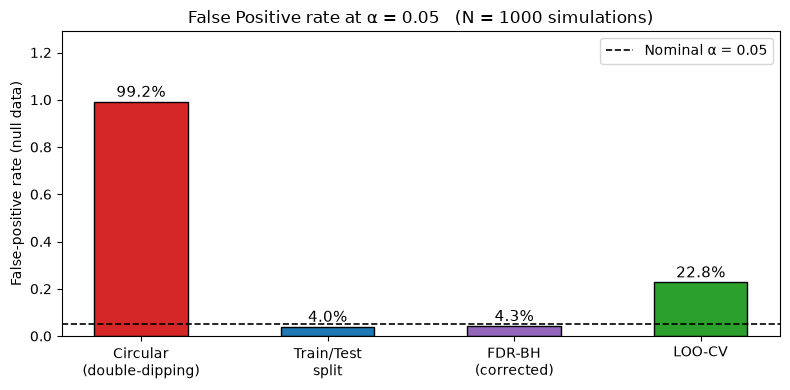

In [5]:
labels = ["Circular\n(double-dipping)", "Train/Test\nsplit", "FDR-BH\n(corrected)", "LOO-CV"]
rates2 = [counts[k] / N_iter2 for k in ("circular", "split", "fdr_bh", "cv")]
colors2 = ["tab:red", "tab:blue", "tab:purple", "tab:green"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, rates2, color=colors2, width=0.5, edgecolor="k")
ax.axhline(alpha2, color="k", linestyle="--", linewidth=1.2, label=f"Nominal α = {alpha2}")
ax.set_ylabel("False-positive rate (null data)")
ax.set_title(f"False Positive rate at α = {alpha2}   (N = {N_iter2} simulations)")
ax.set_ylim(0, max(rates2) * 1.3)
for bar, rate in zip(bars, rates2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4;  max-width: 90%; overflow-x: auto; color: #000000;">

#### A problem with LOO-CV:

LOO-CV removes the *worst* of the circularity, but can you find a subtle weakness?

<details>
<summary><b>Answer:</b></summary>

The 20 folds each leave out a single trial group, so any two folds share 18 of their 19 training groups.
The held-out PRCA values are therefore **not independent** of one another, and they were all
selected against the same fixed `Perf`. Feeding the assembled `PRCA_cv` vector into
`stats.pearsonr` — which assumes 20 independent observations — gives an **anti-conservative**
p-value. We fix this properly with a permutation test below.
</details>

<br>

</div>



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

## Solving the issue with LOO-CV by permutation-based testing

The LOO-CV false-positive rate above is still well above nominal. The problem is not the
cross-validation itself but the **final test**: feeding the assembled `PRCA_cv` vector into
`stats.pearsonr` assumes 20 *independent* observations, whereas the folds share almost all
their data and reuse the same fixed `Perf`, so the values are dependent and the analytic
p-value is anti-conservative.

The fix: keep the cross-validated statistic, but get its significance from a
**label-permutation null** instead of the t-distribution. Shuffling `Perf` and re-running the
*entire* selection + CV pipeline reproduces the same dependence and selection artifact under
the null, so comparing the observed statistic to that null is calibrated.

</div>


In [6]:
# A cross-validated statistic is (approximately) unbiased, but its significance must come from
# a permutation null, not the analytic pearsonr p-value (which assumes independent points).
perm_rng = np.random.default_rng(1)  # local generator: keeps the global rng / results above unchanged


def loo_cv_corr(DA, Perf):
    """The scalar LOO-CV statistic: correlation of held-out PRCA with performance."""
    PRCA, _ = loo_cv_PRCA(DA, Perf)
    mask = ~np.isnan(PRCA)
    if mask.sum() < 3:
        return 0.0
    return stats.pearsonr(PRCA[mask], Perf[mask]).statistic


def loo_cv_perm_pvalue(DA, Perf, n_perm=1000):
    """Significance of the LOO-CV correlation via label permutation.

    Shuffling `Perf` re-runs the *entire* selection + CV pipeline, so the null carries the
    same fold dependence and selection artifact that inflate the analytic p-value. One-sided
    because selection keeps positive-correlation cells (r > 0.1).
    """
    observed = loo_cv_corr(DA, Perf)
    null = np.array([loo_cv_corr(DA, rng.permutation(Perf)) for _ in range(n_perm)])
    p = (1 + np.sum(null >= observed)) / (1 + n_perm)
    return observed, p


for name, D in [("null (no effect)", DA),
                (f"weak effect (k={k})", DA_real),
                (f"strong effect (k={k_strong})", DA_real_strong)]:
    obs, pval = loo_cv_perm_pvalue(D, Perf, n_perm=1000)
    print(f"{name:22s}  observed CV r = {obs:+.3f}   permutation p = {pval:.3f}")


null (no effect)        observed CV r = +0.263   permutation p = 0.273
weak effect (k=0.2)     observed CV r = -0.085   permutation p = 0.619
strong effect (k=0.6)   observed CV r = +0.923   permutation p = 0.001



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

### False-positive rate: analytic vs permutation p-value

Now repeat the null Monte-Carlo (no real effect) and compare, for each dataset, the LOO-CV
decision made with the **analytic** `pearsonr` p-value versus the **permutation** p-value.

**Expected outcome:** the analytic test stays inflated (dependent CV points break its
independence assumption), while the permutation test returns to the nominal α.

</div>


In [7]:
# To make ~40,000 cross-validated fits tractable we use a fast but *mathematically identical*
# LOO: with 19 training groups the rule "r > 0.1 AND p < 0.05" is exactly "r > r_crit",
# because the two-sided p < 0.05 threshold (|r| > 0.456) already implies r > 0.1.
_tc = stats.t.ppf(1 - 0.05 / 2, (Ngroups - 1) - 2)
R_CRIT = _tc / np.sqrt((Ngroups - 1) - 2 + _tc ** 2)


def _corr(a, b):
    a = a - a.mean()
    b = b - b.mean()
    return (a * b).sum() / np.sqrt((a ** 2).sum() * (b ** 2).sum())


def loo_cv_PRCA_fast(DA, Perf):
    """Same LOO-CV PRCA as loo_cv_PRCA, but correlation-only (no p-value) for speed."""
    Ng = DA.shape[0]
    PRCA = np.full(Ng, np.nan)
    for i in range(Ng):
        tr = np.delete(np.arange(Ng), i)
        y = Perf[tr] - Perf[tr].mean()
        Xc = DA[tr] - DA[tr].mean(axis=0)
        r = (Xc * y[:, None]).sum(0) / np.sqrt((Xc ** 2).sum(0) * (y ** 2).sum())
        sel = np.where(r > R_CRIT)[0]
        if sel.size > 0:
            PRCA[i] = DA[i, sel].mean()
    return PRCA


def loo_cv_corr_fast(DA, Perf):
    PRCA = loo_cv_PRCA_fast(DA, Perf)
    mask = ~np.isnan(PRCA)
    if mask.sum() < 3:
        return 0.0
    return _corr(PRCA[mask], Perf[mask])


N_datasets = 200   # null datasets
n_perm_fp  = 200   # label permutations per dataset
alpha_perm = 0.05  # nominal false-positive rate

fp_analytic = 0
fp_perm = 0
for _ in range(N_datasets):
    DA_null = sd_dff * perm_rng.standard_normal((Ngroups, Ncells))
    PRCA = loo_cv_PRCA_fast(DA_null, Perf)
    mask = ~np.isnan(PRCA)
    if mask.sum() < 3:
        continue
    obs = _corr(PRCA[mask], Perf[mask])

    # (1) analytic, one-sided (positive) p from pearsonr on the assembled CV vector
    _, p_two = stats.pearsonr(PRCA[mask], Perf[mask])
    p_analytic = p_two / 2 if obs > 0 else 1.0
    if p_analytic < alpha_perm:
        fp_analytic += 1

    # (2) permutation p: shuffle Perf, rerun the whole selection + CV pipeline
    null = np.array([loo_cv_corr_fast(DA_null, perm_rng.permutation(Perf))
                     for _ in range(n_perm_fp)])
    if (1 + np.sum(null >= obs)) / (1 + n_perm_fp) < alpha_perm:
        fp_perm += 1

print(f"LOO-CV false-positive rate on null data "
      f"({N_datasets} datasets, α = {alpha_perm:.0%}):")
print(f"  analytic pearsonr p  : {fp_analytic / N_datasets:.1%}")
print(f"  permutation p        : {fp_perm / N_datasets:.1%}")
print(f"  nominal α            : {alpha_perm:.0%}")


LOO-CV false-positive rate on null data (200 datasets, α = 5%):
  analytic pearsonr p  : 18.5%
  permutation p        : 5.5%
  nominal α            : 5%



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; color: #000000;">

## Power curves

Here we measure **power** — the true-positive rate on real-effect data — across two parameter sweeps:

1. **Effect-size sweep** — $k$ from 0.1 to 1.0 in steps of 0.1, with $N = 20$ trial groups fixed.
   Shows the minimum effect size each method can reliably detect.

2. **Sample-size sweep** — the number of trial groups $N$ from 5 to 25 in steps of 1, with
   $k = 0.2$ fixed.  Shows how many trial groups each method needs to reach adequate power.

For each combination, `N_iter_power` real-effect datasets are simulated and the
fraction of runs that produce a detection is recorded.  $P$ and the cell activity are
resampled fresh each run so the estimate reflects genuine variability.

> **Note on the circular method:** its "power" includes spurious detections arising
> from the circular selection bias — the high curve is not evidence of a trustworthy
> method, but of an inflated false-positive rate carrying over into real-effect data.

</div>


In [8]:
# repeat imports here so this section can run independently if needed
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import sys
sys.path.append("/code")
from utils import loo_cv_PRCA, fdr_bh_cells

# Set a seed so the notebook is reproducible (remove for fresh random draws)
rng = np.random.default_rng(0)

# Simulation constants (same as Parts 1–3)
Ngroups, Ncells = 20, 200
mean_perf, sd_perf, sd_dff = 75, 8, 1

# 10% of cells are genuinely modulated by performance (the real-effect ground truth)
Nresponsive = round(0.1 * Ncells)
CorrelatedCells = np.arange(0, Nresponsive)


In [9]:
def power_sweep(param_values, param_name, N_iter, alpha, k_fixed=0.2, N_fixed=20):
    """Estimate detection power for each value of k (effect size) or N (number of trial groups).

    Simulates real-effect data for each parameter value and returns the fraction
    of runs where each method correctly reaches a detection at level alpha.

    Parameters
    ----------
    param_values : array-like
    param_name   : 'k' or 'N'
    N_iter       : simulations per parameter value
    alpha        : significance threshold
    k_fixed      : effect size used when sweeping N
    N_fixed      : number of trial groups used when sweeping k
    """
    power = {m: [] for m in ("circular", "loo_cv", "fdr_bh")}

    for val in param_values:
        k_val = float(val) if param_name == "k" else k_fixed
        N_val = int(val)   if param_name == "N" else N_fixed
        counts = {"circular": 0, "loo_cv": 0, "fdr_bh": 0}

        for _ in range(N_iter):
            # Fresh performance scores for this run
            Perf_sim = np.round(sd_perf * rng.standard_normal(N_val) + mean_perf)
            std_P = np.std(Perf_sim, ddof=1)
            if std_P < 1e-10:
                continue

            # Real-effect cell data: performance-correlated cells modulated by performance
            Pscaled_sim = (k_val * sd_dff / std_P) * (Perf_sim - np.mean(Perf_sim))
            DA_sim = sd_dff * rng.standard_normal((N_val, Ncells))
            DA_sim[:, CorrelatedCells] += Pscaled_sim[:, np.newaxis]

            # Circular
            res_s = stats.pearsonr(DA_sim, Perf_sim[:, np.newaxis], axis=0)
            sel_s = np.where((res_s.statistic > 0.1) & (res_s.pvalue < 0.05))[0]
            if sel_s.size > 0:
                _, p_circ = stats.pearsonr(DA_sim[:, sel_s].mean(axis=1), Perf_sim)
                if p_circ < alpha:
                    counts["circular"] += 1

            # LOO-CV
            PRCA_cv_s, _ = loo_cv_PRCA(DA_sim, Perf_sim)
            cv_mask = ~np.isnan(PRCA_cv_s)
            if cv_mask.sum() >= 3:
                _, p_cv = stats.pearsonr(PRCA_cv_s[cv_mask], Perf_sim[cv_mask])
                if p_cv < alpha:
                    counts["loo_cv"] += 1

            # FDR-BH: detection if >=1 cell survives BH at q = alpha
            if fdr_bh_cells(DA_sim, Perf_sim, q=alpha).size > 0:
                counts["fdr_bh"] += 1

        for m in power:
            power[m].append(counts[m] / N_iter)

    return power


In [10]:
N_iter_power = 200   # increase to 500–1000 for smoother curves (takes longer)
alpha_power  = 0.05  # standard threshold for power analysis

k_values = np.round(np.arange(0.1, 1.01, 0.1), 2)   # [0.1, 0.2, ..., 1.0]
N_values = np.arange(5, 26, 1)                        # [5, 6, ..., 25] trial groups

print(f"Running effect-size sweep ({len(k_values)} k values × {N_iter_power} iterations) …")
power_k = power_sweep(k_values, "k", N_iter_power, alpha_power, N_fixed=20)
print("  done.")

print(f"Running sample-size sweep ({len(N_values)} N values × {N_iter_power} iterations) …")
power_N = power_sweep(N_values, "N", N_iter_power, alpha_power, k_fixed=0.2)
print("  done.")


Running effect-size sweep (10 k values × 200 iterations) …
  done.
Running sample-size sweep (21 N values × 200 iterations) …
  done.


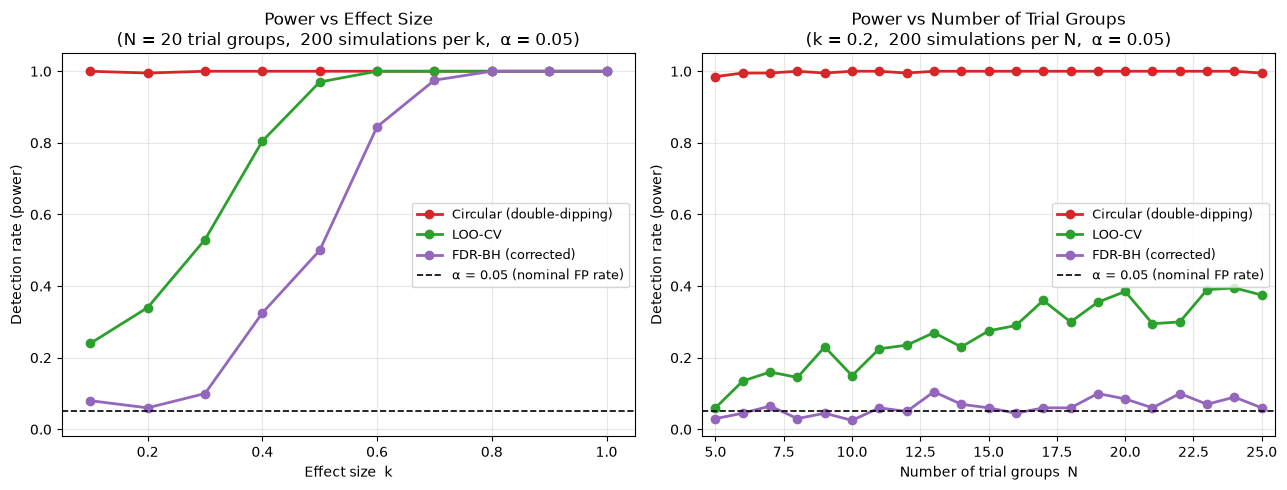

In [11]:
method_styles = {
    "circular": ("tab:red",    "Circular (double-dipping)"),
    "loo_cv":   ("tab:green",  "LOO-CV"),
    "fdr_bh":   ("tab:purple", "FDR-BH (corrected)"),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: power vs effect size k (N=20 trial groups fixed)
ax = axes[0]
for m, (color, label) in method_styles.items():
    ax.plot(k_values, power_k[m], "o-", color=color, label=label, linewidth=2)
ax.axhline(alpha_power, color="k", linestyle="--", linewidth=1.2,
           label=f"α = {alpha_power} (nominal FP rate)")
ax.set_xlabel("Effect size  k")
ax.set_ylabel("Detection rate (power)")
ax.set_title(f"Power vs Effect Size\n(N = 20 trial groups,  {N_iter_power} simulations per k,  α = {alpha_power})")
ax.set_xlim(k_values[0] - 0.05, k_values[-1] + 0.05)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: power vs number of trial groups N (k=0.2 fixed)
ax = axes[1]
for m, (color, label) in method_styles.items():
    ax.plot(N_values, power_N[m], "o-", color=color, label=label, linewidth=2)
ax.axhline(alpha_power, color="k", linestyle="--", linewidth=1.2,
           label=f"α = {alpha_power} (nominal FP rate)")
ax.set_xlabel("Number of trial groups  N")
ax.set_ylabel("Detection rate (power)")
ax.set_title(f"Power vs Number of Trial Groups\n(k = 0.2,  {N_iter_power} simulations per N,  α = {alpha_power})")
ax.set_xlim(N_values[0] - 0.5, N_values[-1] + 0.5)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
